# Load and visualize datasets

In [2]:
import numpy as np 
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
X_1 = np.load('X_1.npy')
X_2 = np.load('X_2.npy')

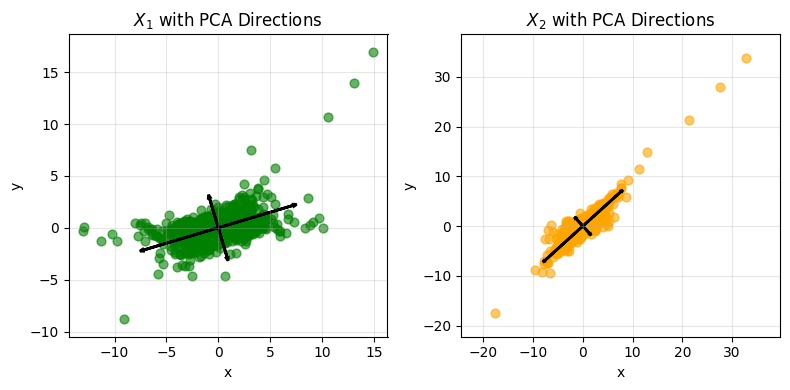

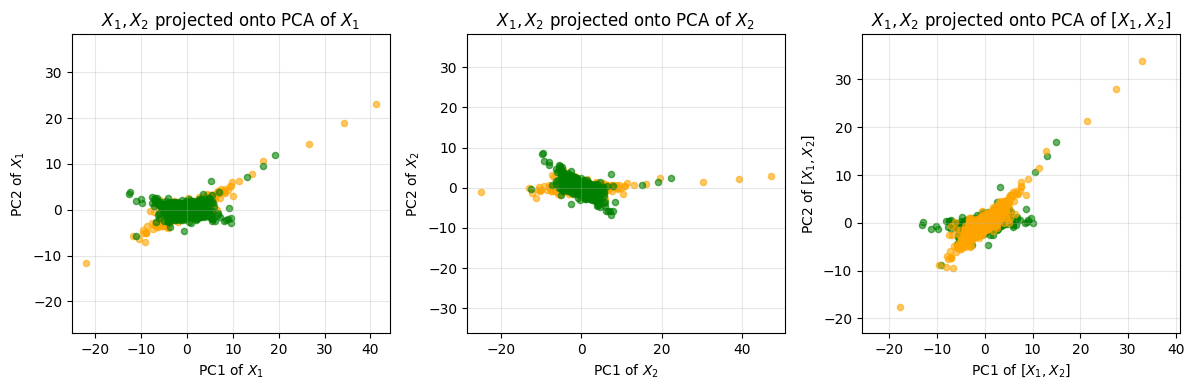

In [6]:
# Plot Student's t-distribution samples with PCA directions
from sklearn.decomposition import PCA

# Compute PCA for both t-distribution datasets
pca_t1 = PCA()
pca_t1.fit(X_1)

pca_t2 = PCA()
pca_t2.fit(X_2)

plt.figure(figsize=(8,4))

# Plot 1: t_samples_1 with PC directions
plt.subplot(1, 2, 1)
plt.scatter(X_1[:, 0], X_1[:, 1], alpha=0.6, s=40, c='green')

# Draw principal component directions as arrows
center = np.mean(X_1, axis=0)
scale = 4.0  # Scale factor for arrow length
for i, (pc, var) in enumerate(zip(pca_t1.components_, pca_t1.explained_variance_)):
    arrow_length = scale * np.sqrt(var)
    plt.arrow(center[0], center[1], 
              pc[0] * arrow_length, pc[1] * arrow_length,
              head_width=0.2, head_length=0.3, linewidth=2,
              label=f'PC{i+1}' if i < 2 else "")
    plt.arrow(center[0], center[1], 
              -pc[0] * arrow_length, -pc[1] * arrow_length,
              head_width=0.2, head_length=0.3, linewidth=2)
plt.title(r'$X_1$ with PCA Directions')
plt.xlabel('x')
plt.ylabel('y')
# plt.title(r'$X_1$')
plt.grid(True, alpha=0.3)
plt.axis('equal')


# Plot 2: t_samples_2 with PC directions
plt.subplot(1, 2, 2)
plt.scatter(X_2[:, 0], X_2[:, 1], alpha=0.6, s=40, c='orange')

# Draw principal component directions as arrows
center = np.mean(X_2, axis=0)
for i, (pc, var) in enumerate(zip(pca_t2.components_, pca_t2.explained_variance_)):
    arrow_length = scale * np.sqrt(var)
    plt.arrow(center[0], center[1], 
              pc[0] * arrow_length, pc[1] * arrow_length,
              head_width=0.2, head_length=0.3, linewidth=2,
              label=f'PC{i+1}' if i < 2 else "")
    plt.arrow(center[0], center[1], 
              -pc[0] * arrow_length, -pc[1] * arrow_length,
              head_width=0.2, head_length=0.3, linewidth=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title(r'$X_2$ with PCA Directions')
plt.grid(True, alpha=0.3)
plt.axis('equal')


plt.tight_layout()

plt.figure(figsize=(12,4))

 # Plot 3: PCA transformed t_samples_1
X_t1 = pca_t1.transform(X_1)
X_t2_t1pca = pca_t1.transform(X_2)
plt.subplot(1, 3, 1)
plt.scatter(X_t2_t1pca[:, 0], X_t2_t1pca[:, 1], alpha=0.6, s=20, c='orange')
plt.scatter(X_t1[:, 0], X_t1[:, 1], alpha=0.6, s=20, c='green')
plt.xlabel(f'PC1 of $X_1$')
plt.ylabel(f'PC2 of $X_1$')
plt.axis('equal')
plt.title(f'$X_1,X_2$ projected onto PCA of $X_1$')
plt.grid(True, alpha=0.3)

# # Plot 4: PCA transformed t_samples_2
X_t2 = pca_t2.transform(X_2)
X_t1_t2pca = pca_t2.transform(X_1)  
plt.subplot(1, 3, 2)
plt.scatter(X_t2[:, 0], X_t2[:, 1], alpha=0.6, s=20, c='orange')
plt.scatter(X_t1_t2pca[:, 0], X_t1_t2pca[:, 1], alpha=0.6, s=20, c='green')
plt.xlabel(f'PC1 of $X_2$')
plt.ylabel(f'PC2 of $X_2$')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.title(f'$X_1,X_2$ projected onto PCA of $X_2$')



## Plot 5: PCA transformed t_samples_1 and t_samples_2 together
plt.subplot(1, 3, 3)
plt.scatter(X_1[:, 0], X_1[:, 1], alpha=0.6, s=20, c='green', label='t_samples_1')
plt.scatter(X_2[:, 0], X_2[:, 1], alpha=0.6, s=20, c='orange', label='t_samples_2')
plt.xlabel(f'PC1 of $[X_1,X_2]$')
plt.ylabel(f'PC2 of $[X_1,X_2]$')
plt.title(f'$X_1,X_2$ projected onto PCA of $[X_1,X_2]$')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()

# MCPCA from datasets

In [1]:
import mcpca

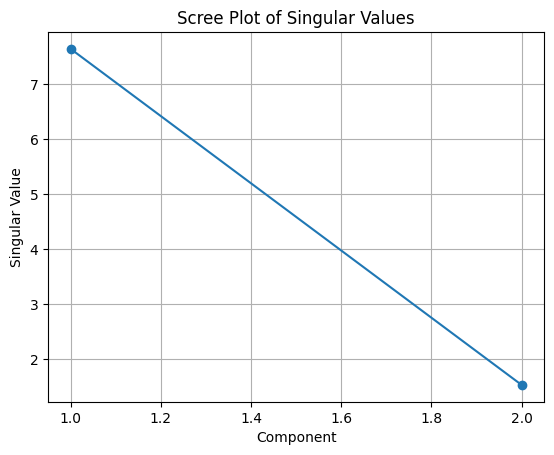

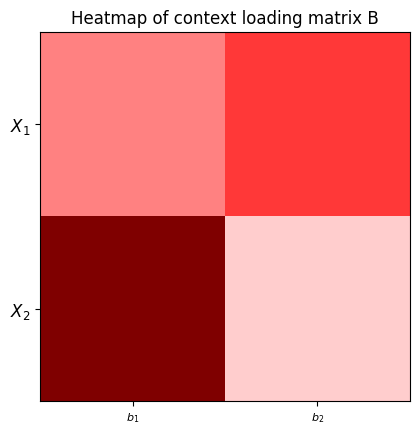

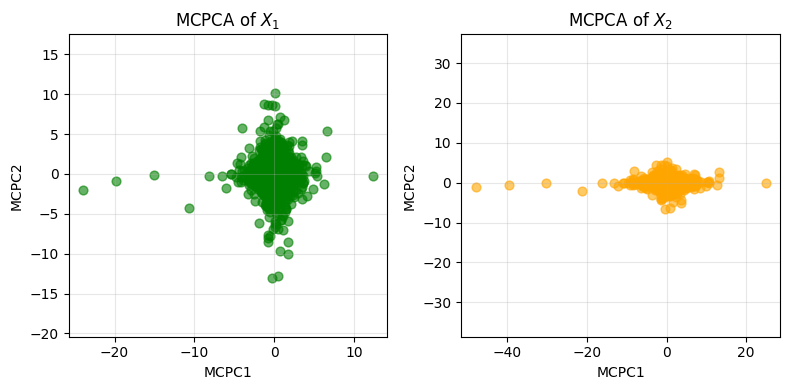

In [5]:
# #mcpca

# pass a number to n_components or pass a rank range to choose from 
model = mcpca.MCPCA(n_components=None, rank_range = [1,2])
# set plot_A = True to visualize MCPC matrix A
# set plot_B = True to visualize loading matrix B
model.fit([X_1, X_2],plot_B = True,scree_plot = True)
mcpca_transformed = model.transform([X_1, X_2], return_list=True)

plt.figure(figsize=(8,4))

plt.subplot(1, 2, 1)
plt.scatter(mcpca_transformed[0][:, 0], mcpca_transformed[0][:, 1], alpha=0.6, s=40, c='green')
plt.axis('equal')
plt.title('MCPCA of $X_1$')
plt.xlabel('MCPC1')
plt.ylabel('MCPC2')
plt.grid(True, alpha=0.3)


plt.subplot(1,2,2)
plt.scatter(mcpca_transformed[1][:, 0], mcpca_transformed[1][:, 1], alpha=0.6, s=40, c='orange')
plt.axis('equal')
plt.xlabel('MCPC1')
plt.ylabel('MCPC2')
plt.title('MCPCA of $X_2$')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [10]:
# access loading matrix B, MCPC matrix A for interpretability and further analysis
B = model.loadings_
A = model.components_
r = model.r_
A,B,r

(array([[-0.70824722,  0.9999912 ],
        [-0.7059645 ,  0.0041948 ]]),
 array([[1.63824306, 2.5282279 ],
        [6.55330696, 0.63202469]]),
 2)

# MCPCA from covariance matrices

In [11]:
# form the tensor of covariance matrices
T = mcpca.cov_tensor([X_1, X_2])
# compute MCPCA decomposition directly
A,B = mcpca.MCPCA_decompose(T,2)